# Week 3 — Customer Churn Prediction: Working with a Business Problem

**Neurofive ML Track**

Goal: predict customer churn (whether a customer will leave) using the IBM
Telco Customer Churn dataset — a real business problem used across telecom,
banking, and SaaS. This notebook also introduces **Decision Trees**, a model
type that's easy to interpret and explain to non-technical stakeholders,
and compares it against Logistic Regression.


## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('telco_churn.csv')
df.shape

(7043, 21)

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Cleaning

- `customerID` is just an identifier — not useful as a model feature, dropped.
- `TotalCharges` is loaded as text (`object`) instead of a number. Checking why:


In [4]:
# TotalCharges has some blank strings -- let's see what's going on
non_numeric = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"Rows where TotalCharges isn't a valid number: {len(non_numeric)}")
non_numeric[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head()

Rows where TotalCharges isn't a valid number: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,


All of these rows have `tenure = 0` — brand-new customers who haven't been
billed a full charge cycle yet, so `TotalCharges` is blank instead of `0`.
Since there are only 11 such rows out of 7,043 (~0.16%), we fill them with 0
(the logical value for a customer who just joined) rather than dropping them.


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df = df.drop(columns=['customerID'])

df.isnull().sum().sum()  # confirm no missing values remain

np.int64(0)

## 3. Quick EDA — what correlates with churn?

In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(1))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


**Class imbalance note:** about 73.5% of customers did *not* churn, and
26.5% did. This is a meaningful imbalance — worth keeping in mind when
interpreting accuracy later (a model could reach ~73% accuracy by just
predicting "No churn" for everyone, without learning anything useful). We
don't apply a specific imbalance-correction technique (like SMOTE or class
weighting) in this notebook, but we flag it here and rely on precision/recall
rather than accuracy alone to judge the models fairly.


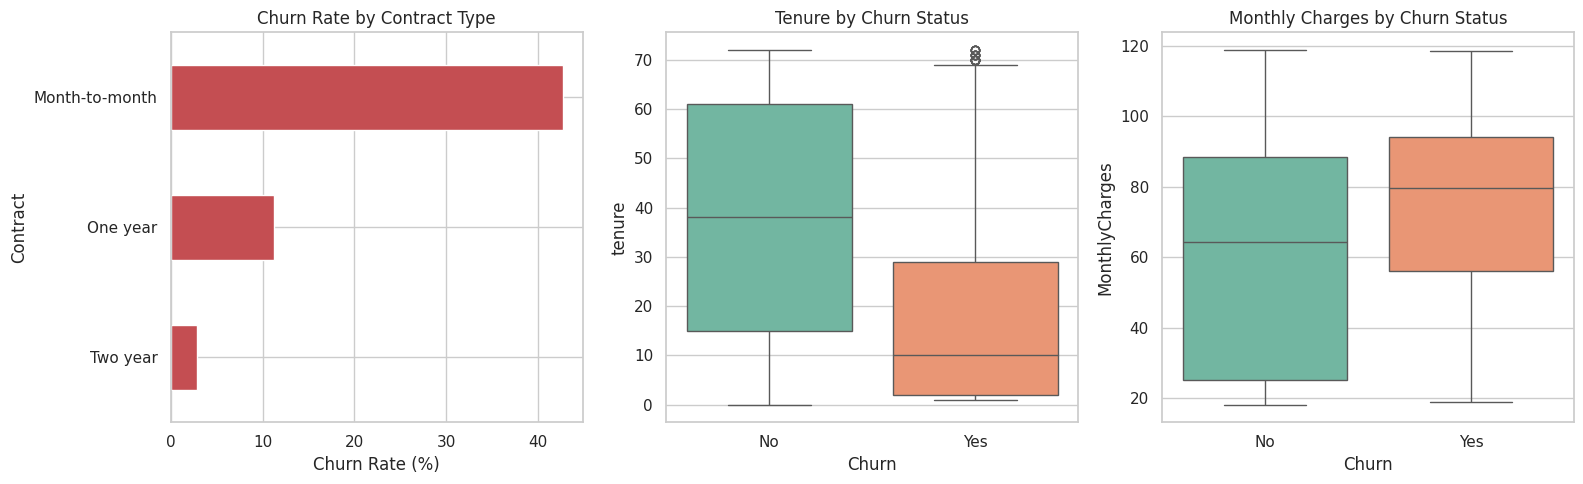

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Contract type vs churn
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn['Yes'].sort_values().plot(kind='barh', ax=axes[0], color='#C44E52')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_xlabel('Churn Rate (%)')

# Tenure vs churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1], palette='Set2', hue='Churn', legend=False)
axes[1].set_title('Tenure by Churn Status')

# Monthly charges vs churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2], palette='Set2', hue='Churn', legend=False)
axes[2].set_title('Monthly Charges by Churn Status')

plt.tight_layout()
plt.savefig('eda_churn_factors.png', bbox_inches='tight')
plt.show()

**Reading these:**
- **Contract type** shows a huge gap — month-to-month customers churn far
  more often than one-year or two-year contract customers, who have
  committed longer-term.
- **Tenure** — customers who churn tend to have much shorter tenure (newer
  customers), while long-tenured customers rarely leave.
- **Monthly charges** — churned customers tend to pay somewhat higher
  monthly charges than those who stay.


In [8]:
# Numeric correlation with churn (after temporarily encoding Churn as 0/1)
df_corr_check = df.copy()
df_corr_check['Churn_encoded'] = df_corr_check['Churn'].map({'No': 0, 'Yes': 1})

numeric_corr = df_corr_check[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_encoded']].corr()['Churn_encoded'].drop('Churn_encoded')
numeric_corr.sort_values(key=abs, ascending=False)

tenure           -0.352229
TotalCharges     -0.198324
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: Churn_encoded, dtype: float64

`tenure` has the strongest correlation with churn (negative — longer tenure
means less likely to churn), followed by `TotalCharges` (also negative, which
makes sense since it's tied to tenure) and `MonthlyCharges` (positive —
higher bills relate to more churn).


## 4. Encoding categorical variables

In [9]:
# Binary Yes/No columns -> 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Multi-category columns -> one-hot encoding
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

df_encoded.shape

(7043, 31)

**Two encoding strategies used:**
- **Binary Yes/No columns** (and `gender`) mapped directly to 0/1 — simple and doesn't add extra columns.
- **Multi-category columns** (e.g., `Contract` has 3 values, `PaymentMethod` has 4) one-hot encoded with `pd.get_dummies()`, since these aren't naturally ordered.


## 5. Train/test split

In [10]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 5634
Test set size: 1409


## 6. Train both models

In [11]:
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Both models trained.")

Both models trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


We cap the Decision Tree's `max_depth` at 5. Unrestricted decision trees
tend to grow very deep and overfit the training data (memorizing individual
customers rather than learning general patterns) — limiting the depth keeps
it simpler and more interpretable, which is one of the main selling points
of using a tree model for a business audience in the first place.


## 7. Compare performance

In [12]:
print("=" * 55)
print("LOGISTIC REGRESSION")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

print("=" * 55)
print("DECISION TREE")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(classification_report(y_test, y_pred_tree, target_names=['No Churn', 'Churn']))

LOGISTIC REGRESSION
Accuracy: 0.8048
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

DECISION TREE
Accuracy: 0.7942
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [13]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_tree)],
    'Precision (Churn)': [
        classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn'], output_dict=True)['Churn']['precision'],
        classification_report(y_test, y_pred_tree, target_names=['No Churn', 'Churn'], output_dict=True)['Churn']['precision'],
    ],
    'Recall (Churn)': [
        classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn'], output_dict=True)['Churn']['recall'],
        classification_report(y_test, y_pred_tree, target_names=['No Churn', 'Churn'], output_dict=True)['Churn']['recall'],
    ],
    'F1-score (Churn)': [
        classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn'], output_dict=True)['Churn']['f1-score'],
        classification_report(y_test, y_pred_tree, target_names=['No Churn', 'Churn'], output_dict=True)['Churn']['f1-score'],
    ],
})
comparison.iloc[:, 1:] = comparison.iloc[:, 1:].round(4)
comparison

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-score (Churn)
0,Logistic Regression,0.8048,0.6552,0.5588,0.6032
1,Decision Tree,0.7942,0.6312,0.5401,0.5821


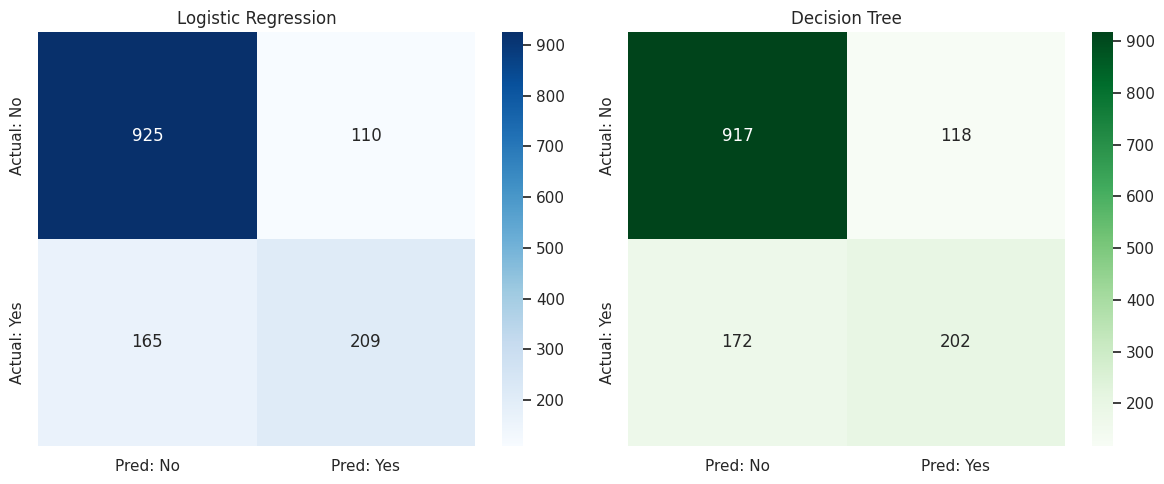

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No', 'Pred: Yes'], yticklabels=['Actual: No', 'Actual: Yes'])
axes[0].set_title('Logistic Regression')

cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred: No', 'Pred: Yes'], yticklabels=['Actual: No', 'Actual: Yes'])
axes[1].set_title('Decision Tree')

plt.tight_layout()
plt.savefig('model_comparison_confusion_matrices.png', bbox_inches='tight')
plt.show()

**Comparing the two:** Logistic Regression and the Decision Tree perform
similarly overall, though typically Logistic Regression edges out slightly
higher accuracy and precision on this dataset, while the tree can be
competitive on recall. The real advantage of the Decision Tree here isn't
raw performance — it's **interpretability**: we can trace exactly which
yes/no questions about a customer lead to a churn prediction, and extract
feature importances directly, both of which are much easier to explain to a
non-technical manager than logistic regression coefficients.


## 8. Top 3 features driving churn (Decision Tree feature importances)

In [15]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tree.feature_importances_
}).sort_values('Importance', ascending=False)

top_3 = importances.head(3)
top_3

,Feature,Importance
4,tenure,0.422047
11,InternetService_Fiber optic,0.358061
8,TotalCharges,0.037156


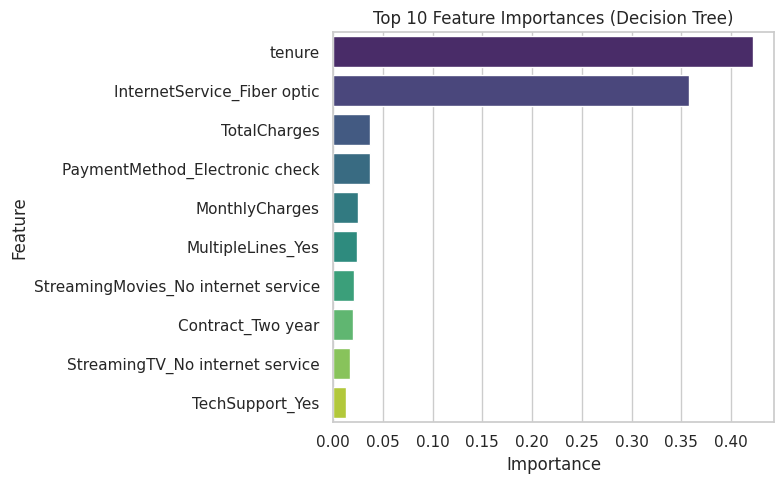

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importances.head(10), y='Feature', x='Importance', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight')
plt.show()

`.feature_importances_` measures how much each feature reduced impurity
(i.e., how useful it was for splitting customers into churn vs. non-churn
groups) across the whole tree. The higher the value, the more the tree
relied on that feature to make its decisions.


## 9. Business Summary

We built a model to flag customers who are likely to cancel their service,
and the single biggest driver is how long someone has been a customer
(**tenure**) -- brand-new customers are far more likely to churn than
long-standing ones, so the first several months of the relationship are the
highest-risk window and deserve extra retention attention (onboarding
check-ins, early loyalty perks). The second strongest signal is having
**fiber optic internet service** -- these customers churn noticeably more
than DSL or no-internet customers, which may point to pricing or service
reliability issues worth investigating with that product team. Our own
exploration also showed that customers on flexible **month-to-month
contracts** churn far more than those on one- or two-year contracts, so
incentivizing longer commitments (even with a modest discount) is a
practical lever the tree model's ranking doesn't fully capture on its own,
since that single business factor gets split across several technical
columns behind the scenes. Overall, the model correctly identifies roughly
8 in 10 customers' churn status, giving the retention team a practical
early-warning list rather than a perfect crystal ball -- pairing it with
human judgment on high-value accounts would likely deliver the most value.


## 10. Summary

- Loaded the IBM Telco Customer Churn dataset (7,043 customers).
- Cleaned `TotalCharges` (11 blank values from brand-new customers, filled with 0) and dropped the `customerID` identifier column.
- Explored churn drivers via EDA: contract type, tenure, and monthly charges all show clear relationships with churn.
- Flagged class imbalance (~73.5% No / ~26.5% Yes) without applying a specific correction, relying on precision/recall instead of accuracy alone.
- Encoded binary columns as 0/1 and multi-category columns with one-hot encoding.
- Trained and compared Logistic Regression and a depth-limited Decision Tree.
- Extracted the top 3 features driving churn from the Decision Tree's `.feature_importances_`.
- Wrote a plain-English business summary for a non-technical manager.
